# EDA — Populism and Political Corruption (V-Dem / V-Party)

Research question: do countries governed by populist parties exhibit higher political
corruption, which dimension is most affected, and in which temporal direction does the
relationship run?

This notebook covers:
- **Section 0** — Setup & connection
- **Section 1** — Data overview & coverage

See `notes_for_report.md` at the repo root for the full write-up of decisions and findings.

## Section 0 — Setup & connection

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid")
pl.Config.set_tbl_rows(20)

# Window enforced throughout: V-Party expert-coded variables only exist 1970-2019.
ANALYSIS_START_YEAR = 1970
ANALYSIS_END_YEAR = 2019

DB_PATH = Path("../data/duckdb/vdem.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

In [2]:
# Confirm the expected tables are present.
pl.read_database(
    "SELECT table_schema, table_name FROM information_schema.tables ORDER BY 1, 2",
    con,
)

table_schema,table_name
str,str
"""meta""","""analysis_window"""
"""meta""","""import_summary"""
"""raw""","""vdem_country_year"""
"""raw""","""vparty_country_party_date"""


## Section 1 — Data overview & coverage

### 1a. Temporal & geographic coverage, 1970–2019

In [3]:
coverage_summary = pl.read_database(
    f"""
    SELECT
        'vdem_country_year' AS table_name,
        MIN(year) AS min_year,
        MAX(year) AS max_year,
        COUNT(DISTINCT country_id) AS n_countries,
        COUNT(*) AS n_rows
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}

    UNION ALL

    SELECT
        'vparty_country_party_date' AS table_name,
        MIN(year) AS min_year,
        MAX(year) AS max_year,
        COUNT(DISTINCT country_id) AS n_countries,
        COUNT(*) AS n_rows
    FROM raw.vparty_country_party_date
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    """,
    con,
)
coverage_summary

table_name,min_year,max_year,n_countries,n_rows
str,i64,i64,i64,i64
"""vdem_country_year""",1970,2019,182,8454
"""vparty_country_party_date""",1970,2019,178,7518


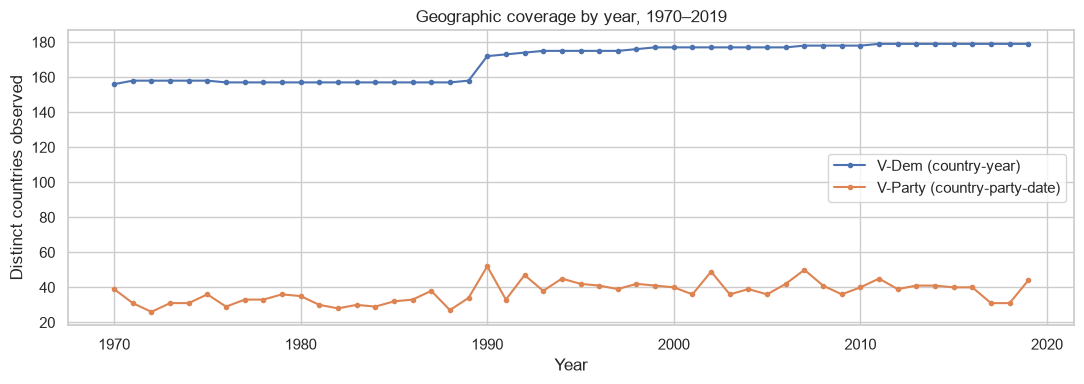

In [4]:
# Geographic density by year: V-Dem is (near-)complete every year; V-Party is
# only observed in years where some country held an election. This is the direct
# evidence for the forward-fill assumption documented in notes_for_report.md.
vdem_by_year = pl.read_database(
    f"""
    SELECT year, COUNT(DISTINCT country_id) AS n_countries
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

vparty_by_year = pl.read_database(
    f"""
    SELECT year, COUNT(DISTINCT country_id) AS n_countries
    FROM raw.vparty_country_party_date
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vdem_by_year["year"], vdem_by_year["n_countries"],
        label="V-Dem (country-year)", marker="o", markersize=3)
ax.plot(vparty_by_year["year"], vparty_by_year["n_countries"],
        label="V-Party (country-party-date)", marker="o", markersize=3)
ax.set_xlabel("Year")
ax.set_ylabel("Distinct countries observed")
ax.set_title("Geographic coverage by year, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

### 1b. Missing values for the 7 key variables, 1970–2019

5 corruption variables (V-Dem, country-year grain) + 2 populism/government variables
(V-Party, party-date grain). Missingness is computed as % of rows null within each
source table, by year.

In [5]:
KEY_VARIABLES = [
    "v2x_corr",
    "v2x_execorr",
    "v2x_pubcorr",
    "v2lgcrrpt",
    "v2jucorrdc",
    "v2xpa_popul",
    "v2pagovsup",
]

vdem_missing = pl.read_database(
    f"""
    SELECT
        year,
        100.0 * SUM(CASE WHEN v2x_corr IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2x_corr,
        100.0 * SUM(CASE WHEN v2x_execorr IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2x_execorr,
        100.0 * SUM(CASE WHEN v2x_pubcorr IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2x_pubcorr,
        100.0 * SUM(CASE WHEN v2lgcrrpt IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2lgcrrpt,
        100.0 * SUM(CASE WHEN v2jucorrdc IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2jucorrdc
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

vparty_missing = pl.read_database(
    f"""
    SELECT
        year,
        100.0 * SUM(CASE WHEN v2xpa_popul IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2xpa_popul,
        100.0 * SUM(CASE WHEN v2pagovsup IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2pagovsup
    FROM raw.vparty_country_party_date
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

# Reindex to the full year range: V-Party has no rows at all for a year with no
# elections anywhere, which must show as 100% missing rather than being dropped.
all_years = pl.DataFrame({"year": list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))})
missing_wide = (
    all_years
    .join(vdem_missing, on="year", how="left")
    .join(vparty_missing, on="year", how="left")
    .with_columns([pl.col(v).fill_null(100.0) for v in ["v2xpa_popul", "v2pagovsup"]])
    .sort("year")
)
missing_wide.head()

year,v2x_corr,v2x_execorr,v2x_pubcorr,v2lgcrrpt,v2jucorrdc,v2xpa_popul,v2pagovsup
i64,f64,f64,f64,f64,f64,f64,f64
1970,1.282051,0.641026,0.641026,25.0,1.282051,6.741573,6.741573
1971,1.265823,0.632911,0.632911,24.050633,1.265823,12.345679,12.345679
1972,1.265823,0.632911,0.632911,20.886076,1.265823,11.392405,13.924051
1973,1.265823,0.632911,0.632911,17.088608,1.265823,22.916667,22.916667
1974,1.265823,0.632911,0.632911,18.35443,1.265823,10.752688,10.752688


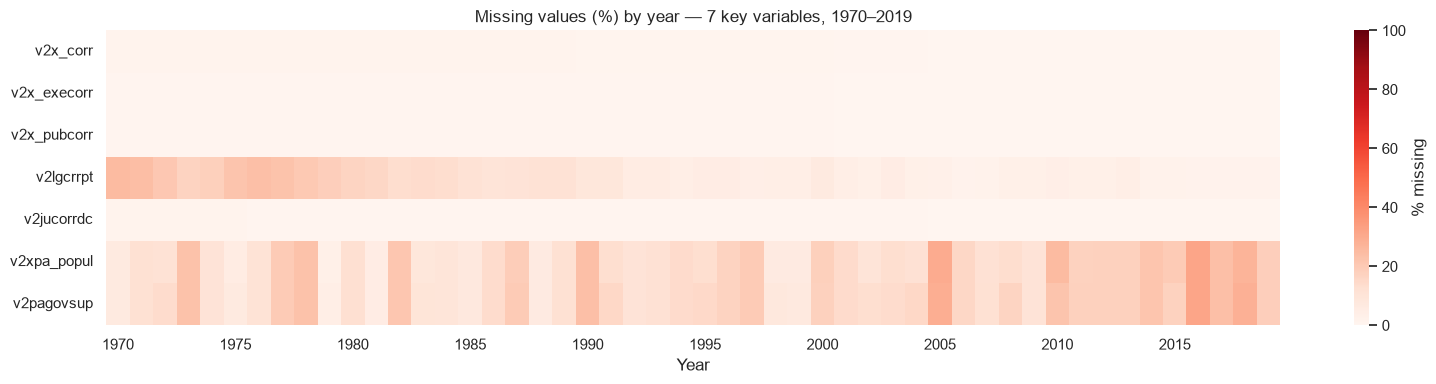

In [6]:
heatmap_data = missing_wide.select(KEY_VARIABLES).to_numpy().T  # shape (7, n_years)
years = missing_wide["year"].to_list()

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    vmin=0,
    vmax=100,
    yticklabels=KEY_VARIABLES,
    xticklabels=[y if y % 5 == 0 else "" for y in years],
    cbar_kws={"label": "% missing"},
    ax=ax,
)
ax.set_title("Missing values (%) by year — 7 key variables, 1970–2019")
ax.set_xlabel("Year")
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

The V-Party rows (`v2xpa_popul`, `v2pagovsup`) show much higher and spikier missingness
than the V-Dem corruption rows, because V-Party is sparse outside election years — this
is the same pattern as the line chart above, expressed as missingness rather than country
counts. `v2lgcrrpt` is structurally higher than the other corruption variables because it
is set to missing for countries without a legislature.

### 1c. Summary table (report-ready)

In [7]:
var_counts = pl.read_database(
    f"""
    SELECT 'v2x_corr' AS variable, 'vdem_country_year' AS source_table,
           COUNT(*) AS n_total, COUNT(v2x_corr) AS n_non_null
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2x_execorr', 'vdem_country_year', COUNT(*), COUNT(v2x_execorr)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2x_pubcorr', 'vdem_country_year', COUNT(*), COUNT(v2x_pubcorr)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2lgcrrpt', 'vdem_country_year', COUNT(*), COUNT(v2lgcrrpt)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2jucorrdc', 'vdem_country_year', COUNT(*), COUNT(v2jucorrdc)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2xpa_popul', 'vparty_country_party_date', COUNT(*), COUNT(v2xpa_popul)
    FROM raw.vparty_country_party_date WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2pagovsup', 'vparty_country_party_date', COUNT(*), COUNT(v2pagovsup)
    FROM raw.vparty_country_party_date WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    """,
    con,
)

# Static metadata, documented in notes_for_report.md — "Variables of Interest".
metadata = pl.DataFrame({
    "variable": KEY_VARIABLES,
    "description": [
        "Composite political corruption index",
        "Executive corruption index",
        "Public sector corruption index",
        "Legislative corruption (missing if no legislature)",
        "Judicial corruption decisions",
        "Populism index (party-level)",
        "Party government status (0=senior governing partner)",
    ],
    "coding_direction": [
        "0=clean, 1=corrupt",
        "0=clean, 1=corrupt",
        "0=clean, 1=corrupt",
        "0=corrupt, 4=clean",
        "0=corrupt, 4=clean",
        "0=not populist, 1=populist",
        "categorical (0-4)",
    ],
})

summary_table = (
    metadata
    .join(var_counts, on="variable", how="left")
    .with_columns((100 * pl.col("n_non_null") / pl.col("n_total")).round(1).alias("pct_non_null"))
    .select([
        "variable", "source_table", "description", "coding_direction",
        "n_total", "n_non_null", "pct_non_null",
    ])
)
summary_table

variable,source_table,description,coding_direction,n_total,n_non_null,pct_non_null
str,str,str,str,i64,i64,f64
"""v2x_corr""","""vdem_country_year""","""Composite political corruption…","""0=clean, 1=corrupt""",8454,8388,99.2
"""v2x_execorr""","""vdem_country_year""","""Executive corruption index""","""0=clean, 1=corrupt""",8454,8423,99.6
"""v2x_pubcorr""","""vdem_country_year""","""Public sector corruption index""","""0=clean, 1=corrupt""",8454,8423,99.6
"""v2lgcrrpt""","""vdem_country_year""","""Legislative corruption (missin…","""0=corrupt, 4=clean""",8454,7707,91.2
"""v2jucorrdc""","""vdem_country_year""","""Judicial corruption decisions""","""0=corrupt, 4=clean""",8454,8413,99.5
"""v2xpa_popul""","""vparty_country_party_date""","""Populism index (party-level)""","""0=not populist, 1=populist""",7518,6307,83.9
"""v2pagovsup""","""vparty_country_party_date""","""Party government status (0=sen…","""categorical (0-4)""",7518,6280,83.5


## Section 2 — Distribution of the populism score (governing party)

### 2a. Histogram of `v2xpa_popul` for senior governing parties

Restricting to senior governing parties (`v2pagovsup == 0`) within 1970-2019 — the same population used for the primary populist-governance measure (see `notes_for_report.md`, Methodology Decisions). Mean, median, and 75th percentile are overlaid to inform an empirical threshold for "populist government".

In [8]:
gov_popul = pl.read_database(
    f"""
    SELECT v2xpa_popul
    FROM raw.vparty_country_party_date
    WHERE v2pagovsup = 0
      AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2xpa_popul IS NOT NULL
    """,
    con,
)

popul_values = gov_popul["v2xpa_popul"]
popul_mean = popul_values.mean()
popul_median = popul_values.median()
popul_p75 = popul_values.quantile(0.75)

popul_mean, popul_median, popul_p75

(0.3296781326781327, 0.274, 0.47)

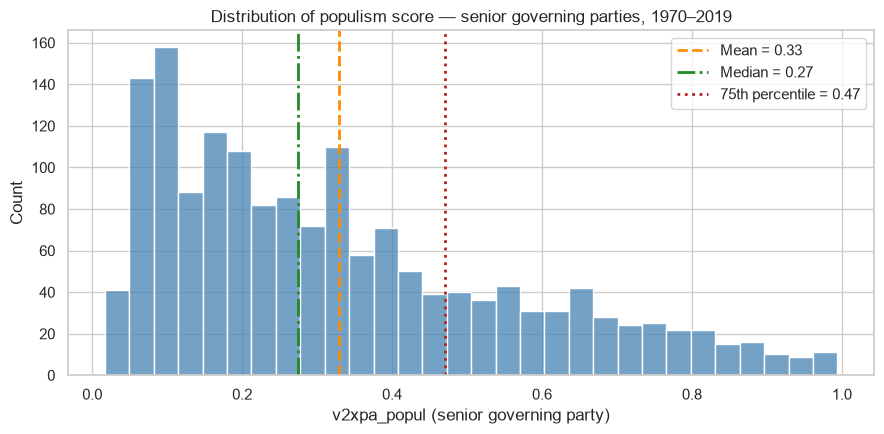

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(popul_values, bins=30, color="steelblue", ax=ax)

ax.axvline(popul_mean, color="darkorange", linestyle="--", linewidth=2,
           label=f"Mean = {popul_mean:.2f}")
ax.axvline(popul_median, color="forestgreen", linestyle="-.", linewidth=2,
           label=f"Median = {popul_median:.2f}")
ax.axvline(popul_p75, color="firebrick", linestyle=":", linewidth=2,
           label=f"75th percentile = {popul_p75:.2f}")

ax.set_xlabel("v2xpa_popul (senior governing party)")
ax.set_ylabel("Count")
ax.set_title("Distribution of populism score — senior governing parties, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

## Findings & report notes

- Threshold for 'populist government' to be decided empirically based on distribution — see section 2a.